<a href="https://colab.research.google.com/github/Gonza03s/intro-analisis-de-datos/blob/master/ley_grandes_numeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#*Ley de los Grandes Números*

#####La Ley de los Grandes Números (LGN) es un principio de la probabilidad que dice, en términos sencillos:

#####Cuantas más veces observamos un fenómeno aleatorio, más se aproxima el promedio observado al valor esperado o promedio teórico de ese fenómeno.

###Ejemplo sencillo: lanzar una moneda

#####Supongamos una moneda equilibrada.

#####Teóricamente:

* Probabilidad de cara = 50 %
* Probabilidad de cruz = 50 %

#####Si la lanzamos 10 veces, podríamos obtener:
* 7 caras y 3 cruces → 70 % caras

#####No hay ningún problema: con pocas observaciones puede haber bastante variación.

#####Ahora imaginemos que la lanzamos:
| Lanzamientos | % de caras observado |
| -----------: | -------------------: |
|           10 |                 70 % |
|          100 |                 54 % |
|        1.000 |               50,8 % |
|       10.000 |               50,2 % |
|      100.000 |               49,9 % |

#####A medida que aumentamos la cantidad de observaciones, el porcentaje observado tiende a acercarse al 50 %.
#####Eso es la Ley de los Grandes Números.

#####Cada lanzamiento sigue siendo independiente. La ley habla del comportamiento del promedio cuando tenemos muchas observaciones.

#Compañía de Seguros

#####Compañía de seguros de automóviles

#####La empresa no puede saber si un conductor particular tendrá un accidente durante el próximo año.

#####Pero puede analizar miles de conductores.
#####Supongamos que históricamente:
* De cada 1.000 conductores, aproximadamente 50 tienen un accidente por año.
#####Entonces la tasa histórica de accidentes es aproximadamente:
* 5 %

#####Si la empresa asegura solamente 20 personas
#####Podría ocurrir:
* 0 accidentes
#####o:
* 2 accidentes
#####o:
* 5 accidentes
#####Hay mucha variabilidad.

#####Si asegura 100.000 personas
#####Es mucho más razonable esperar que la cantidad de accidentes se encuentre relativamente cerca del comportamiento histórico.
#####Por ejemplo:
* 100.000 × 5 % ≈ 5.000 accidentes
#####No significa que necesariamente habrá exactamente 5.000 accidentes.
#####Podrían ser 4.850, 5.120, 5.300, etc.
#####Pero el comportamiento agregado es mucho más estable y predecible.

#####**¿Por qué esto es fundamental para el negocio?**
#####Porque permite que la empresa pueda estimar:
* cantidad esperada de siniestros;
* costos esperados;
* primas de seguros;
* reservas necesarias;
* rentabilidad.

#####La empresa no necesita predecir exactamente qué le ocurrirá a Juan.
#####Necesita que el comportamiento de miles o millones de clientes sea suficientemente estable.



#Ejemplo Práctico con NumPy

In [ ]:
import numpy as np

lanzamientos = np.random.randint(0, 2, 10000)

promedio = lanzamientos.mean()

print(promedio)

# Como 0 representa cruz y 1 representa cara, el promedio representa aproximadamente la proporción de caras.

0.492


In [ ]:
# Podríamos probar diferentes cantidades
for n in [10, 100, 1000, 10000]:
    lanzamientos = np.random.randint(0, 2, n)
    print(n, lanzamientos.mean())

# al aumentar n, el promedio tiende a acercarse a 0.5

10 0.3
100 0.52
1000 0.488
10000 0.4932


#Ejemplo Práctico: Analizar el Tiempo de Entrega de una Tienda Online

#####Trabajamos como analistas de datos en una empresa de comercio electrónico.
#####El área de operaciones nos pregunta:
>"_¿Cuánto demora, en promedio, la entrega de nuestros pedidos?"_
#####Tenemos los tiempos de entrega, expresados en días.

In [ ]:
# Comenzamos con pocos pedidos
# Tenemos solamente 10 pedidos:
import numpy as np

entregas = np.array([2, 3, 4, 2, 5, 3, 2, 8, 4, 3])

promedio = np.mean(entregas)

print(promedio)

3.6


######Podríamos decir:
>_"El tiempo promedio de entrega es de 3,6 días."_
#####Pero todavía tenemos muy pocos pedidos.

In [ ]:
# ¿Qué pasa cuando incorporamos más pedidos?
# Podemos simular que cada vez tenemos más información:

import numpy as np

np.random.seed(42)

entregas = np.random.normal(
    loc=4,
    scale=1.5,
    size=10000
)

for n in [10, 50, 100, 500, 1000, 5000, 10000]:
    promedio = np.mean(entregas[:n])
    print(f"{n:5} pedidos → {promedio:.2f} días")

   10 pedidos → 4.67 días
   50 pedidos → 3.66 días
  100 pedidos → 3.84 días
  500 pedidos → 4.01 días
 1000 pedidos → 4.03 días
 5000 pedidos → 4.01 días
10000 pedidos → 4.00 días


#####Observamos que con pocos pedidos el promedio puede variar bastante.
#####A medida que incorporamos más pedidos, el promedio comienza a estabilizarse alrededor de 4 días.

#####**¿Dónde está la Ley de los Grandes Números?**
#####Tenemos una población de pedidos cuyo tiempo de entrega tiene un valor esperado de aproximadamente 4 días.
* Cuando analizamos 10 pedidos nuestro promedio puede ser bastante diferente de 4.
* Pero cuando analizamos 10.000 pedidos el promedio observado tiende a acercarse mucho más al valor esperado.

Pocos datos<br>
↓<br>
Mayor variabilidad del promedio<br>
↓<br>
Más datos<br>
↓<br>
Mayor estabilidad del promedio

#####El gerente pregunta:

>_"¿Podemos afirmar que nuestros pedidos tardan aproximadamente 4 días?"_

#####El analista no debería responder solamente calculando mean() sobre 10 pedidos.
#####Podría decir:
>_"Con una muestra de 10 pedidos, el promedio es de 4,67 días, pero la estimación tiene bastante variabilidad. Al analizar 10.000 pedidos, el promedio se estabiliza alrededor de 4 días."_

#####Incluso podemos visualizar cómo se estabiliza

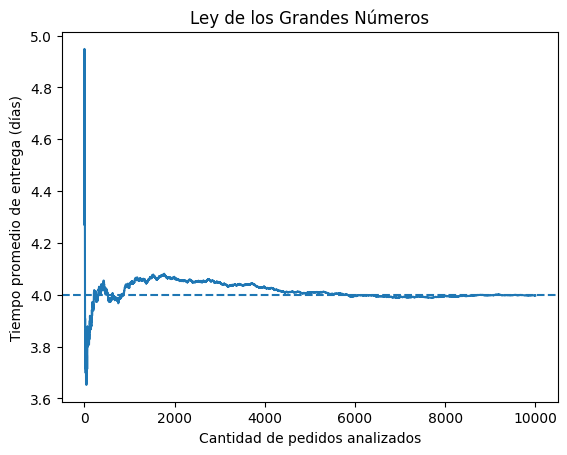

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

entregas = np.random.normal(
    loc=4,
    scale=1.5,
    size=10000
)

promedios = np.cumsum(entregas) / np.arange(1, len(entregas) + 1)

plt.plot(promedios)
plt.axhline(4, linestyle="--")

plt.xlabel("Cantidad de pedidos analizados")
plt.ylabel("Tiempo promedio de entrega (días)")
plt.title("Ley de los Grandes Números")
plt.show()

# La línea del promedio puede oscilar bastante al principio, pero se va estabilizando alrededor de 4 días.

#Resúmen


#####La Ley de los Grandes Números nos dice que, al aumentar la cantidad de observaciones, el promedio obtenido de los datos tiende a acercarse al valor esperado. Por eso, en análisis de datos, trabajar con una cantidad suficiente de observaciones permite obtener estimaciones más estables y representativas.

#####Más datos no significa automáticamente mejores datos.

#####Si tenemos 1 millón de registros con errores, sesgos o datos mal recolectados, seguimos teniendo un problema de calidad.